# **Breast Cancer Classification Pipeline**

This project aims to develope and evaluate a **machine learning pipeline for breast cancer classification**, predicting whether it is **benign or malignant** based on diagnostic features.

Four classification models are implemented and compared: **Logistic Regression**, **Support Vector Machine (SVM)**, **k-Nearest Neighbors (KNN)** and **Linear Discriminant Analysis (LDA)**.

The notebook follows a machine learning workflow including data loading, exploratory analysis, preprocessing, model training, and performance evaluation.

## **IMPORTS AND SET UP**

In [1]:
# Core scientific libraries
import numpy as np
import pandas as pd

# Utility functions
from pandas import set_option        # pandas display options
from google.colab import files       # file upload in Colab
import os, urllib.request            # file system + URL download

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: data handling, models, and metrics
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, auc,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report, precision_recall_curve,average_precision_score
)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Visualization theme (consistent across plots)
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# SVM
from sklearn.svm import SVC

# Saving
import saving
import importlib
importlib.reload(saving)
saving.setup_folders()

## **DATA COLLECTION**

In [2]:
# Get the data the respective URL
df = pd.read_csv(r"https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data",header = None)

# Save raw dataset
df.to_csv("data/raw/breast_cancer_wisconsin.csv", index=False)

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


More details can be found at https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic and are summarized below:

Attribute Information

1. **ID number** : unique sample identifier
2. **Diagnosis**  
   - M = malignant  
   - B = benign  
3. **Features (columns 3–32):**  

Ten real-valued features are computed for each cell nucleus:

a. **Radius** : mean of distances from center to points on the perimeter  
b. **Texture** : standard deviation of gray-scale values  
c. **Perimeter**  
d. **Area**  
e. **Smoothness** : local variation in radius lengths  
f. **Compactness** : (perimeter^2 / area - 1.0 )   
g. **Concavity** : severity of concave portions of the contour  
h. **Concave points** : number of concave portions of the contour  
i. **Symmetry**  
j. **Fractal dimension** : "coastline approximation" − 1




###**Column labeling of the dataset**

Each sample is described by 10 base morphological features of the cell nucleus.
For each feature, three statistical descriptors are provided: mean, standard error (se), and worst.

Column names are generated by combining each feature with its corresponding statistic
(e.g. `radius_mean`, `radius_se`, `radius_worst`).

Two additional columns are added at the beginning of the DataFrame:
- `ID`
- `Diagnosis`

The resulting column list is assigned to the DataFrame to improve readability
and prepare the dataset for downstream machine learning analysis.


In [3]:
base_features = ['radius','texture','perimeter','area','smoothness',
         'compactness','concavity','concave_points','symmetry','fractal_dimension']
stats = ['mean','se','worst']
feature_cols = [f"{b}_{s}" for b in base_features for s in stats]

df.columns = ['ID','Diagnosis'] + feature_cols
df.head()

,ID,Diagnosis,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Adjust data formatting for float variables
# With this only appearence is changed, not the value
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
df.head()

,ID,Diagnosis,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,...,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,842517,M,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,...,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,84300903,M,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,...,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,84348301,M,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,...,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,84358402,M,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,...,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08


## **EXPLORATORY DATA ANALYSIS**

**Exploratory Data Analysis (EDA)** is performed to understand the structure and main characteristics of the dataset.  
This step includes inspecting variables, checking data types and missing values, and exploring feature distributions and relationships.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   radius_se                569 non-null    float64
 4   radius_worst             569 non-null    float64
 5   texture_mean             569 non-null    float64
 6   texture_se               569 non-null    float64
 7   texture_worst            569 non-null    float64
 8   perimeter_mean           569 non-null    float64
 9   perimeter_se             569 non-null    float64
 10  perimeter_worst          569 non-null    float64
 11  area_mean                569 non-null    float64
 12  area_se                  569 non-null    float64
 13  area_worst               569 non-null    float64
 14  smoothness_mean          5

In [6]:
# Dataset size
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Total missing values
print("\nMissing values:", df.isna().sum().sum())

The dataset has 569 rows and 32 columns.

Missing values: 0


The ID feature does not contain predictive information, so it is removed before training the model.

In [7]:
df = df.drop(columns=['ID'])
df.head()

,Diagnosis,radius_mean,radius_se,radius_worst,texture_mean,texture_se,texture_worst,perimeter_mean,perimeter_se,perimeter_worst,...,concavity_worst,concave_points_mean,concave_points_se,concave_points_worst,symmetry_mean,symmetry_se,symmetry_worst,fractal_dimension_mean,fractal_dimension_se,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.00,0.12,0.28,0.30,0.15,0.24,...,25.38,17.33,184.60,2019.00,0.16,0.67,0.71,0.27,0.46,0.12
1,M,20.57,17.77,132.90,1326.00,0.08,0.08,0.09,0.07,0.18,...,24.99,23.41,158.80,1956.00,0.12,0.19,0.24,0.19,0.28,0.09
2,M,19.69,21.25,130.00,1203.00,0.11,0.16,0.20,0.13,0.21,...,23.57,25.53,152.50,1709.00,0.14,0.42,0.45,0.24,0.36,0.09
3,M,11.42,20.38,77.58,386.10,0.14,0.28,0.24,0.11,0.26,...,14.91,26.50,98.87,567.70,0.21,0.87,0.69,0.26,0.66,0.17
4,M,20.29,14.34,135.10,1297.00,0.10,0.13,0.20,0.10,0.18,...,22.54,16.67,152.20,1575.00,0.14,0.20,0.40,0.16,0.24,0.08


### **Descriptive statistics**

Compute summary statistics (mean, std, quartiles, min, max) for all numerical features to inspect their distributions and scales.

In [8]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.00,14.13,3.52,6.98,11.70,13.37,15.78,28.11
radius_se,569.00,19.29,4.30,9.71,16.17,18.84,21.80,39.28
radius_worst,569.00,91.97,24.30,43.79,75.17,86.24,104.10,188.50
texture_mean,569.00,654.89,351.91,143.50,420.30,551.10,782.70,2501.00
texture_se,569.00,0.10,0.01,0.05,0.09,0.10,0.11,0.16
texture_worst,569.00,0.10,0.05,0.02,0.06,0.09,0.13,0.35
perimeter_mean,569.00,0.09,0.08,0.00,0.03,0.06,0.13,0.43
perimeter_se,569.00,0.05,0.04,0.00,0.02,0.03,0.07,0.20
perimeter_worst,569.00,0.18,0.03,0.11,0.16,0.18,0.20,0.30
area_mean,569.00,0.06,0.01,0.05,0.06,0.06,0.07,0.10


Some of the features are on very different scales (e.g., area_mean vs smoothness_mean), suggesting that feature scaling may be necessary before training.

### **Class distribution analysis**

Inspect the balance of the target variable (malignant M vs benign B).

Absolute counts:
Diagnosis
B    357
M    212
Name: count, dtype: int64


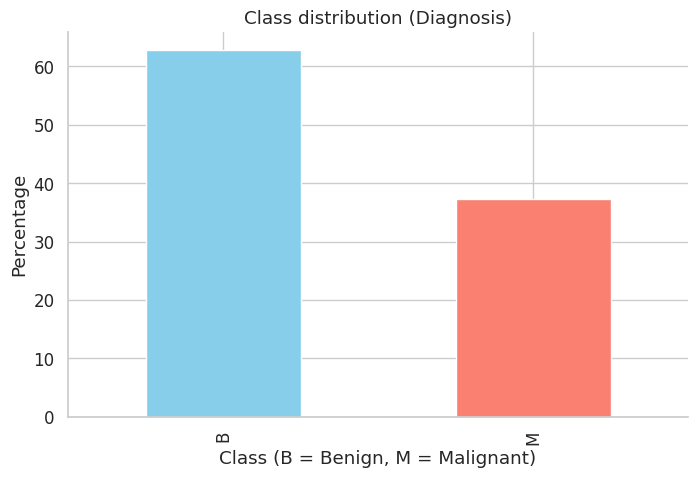


Percentages per class:
B: 62.7%
M: 37.3%


In [9]:
# Absolute counts
counts = df['Diagnosis'].value_counts().sort_index()
print("Absolute counts:")
print(counts)

# Percentages
percentages = df['Diagnosis'].value_counts(normalize=True).sort_index() * 100

# Plot
ax = percentages.plot(kind='bar', color=['skyblue', 'salmon'])

ax.set_title('Class distribution (Diagnosis)')
ax.set_xlabel('Class (B = Benign, M = Malignant)')
ax.set_ylabel('Percentage')

# Save plot
saving.save_figure("class_distribution")

plt.show()

print("\nPercentages per class:")
for cls, val in percentages.round(1).items():
    print(f"{cls}: {val}%")

Although the imbalance is not extreme, it may still influence the model, potentially favoring the majority class. For this reason, evaluation metrics beyond accuracy, such as precision, recall, and F1-score, will be considered to obtain a more complete assessment of model performance.

###**Feature analysis by diagnosis**

Analyze the distribution of selected numerical features (radius_mean, texture_mean and area_mean) across the two diagnosis classes (benign and malignant).  

These features were selected as representative size- and texture-related measurements for an initial exploratory comparison.

By comparing their density distributions, we aim to visually assess whether these features show different patterns between classes and may therefore have discriminative potential.

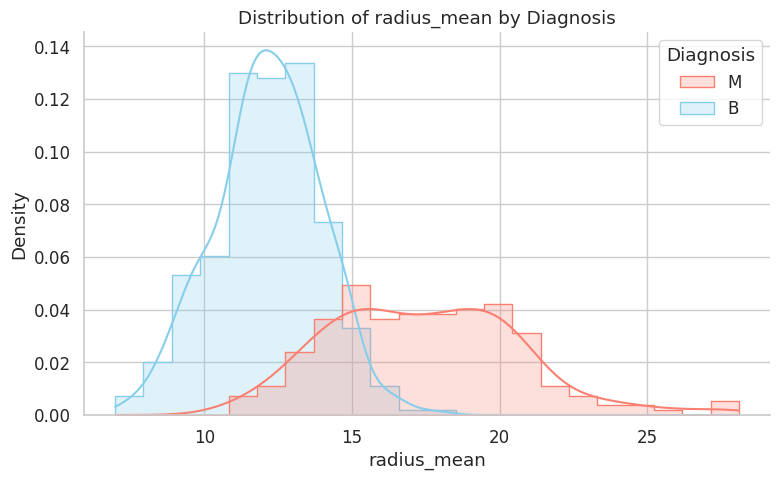

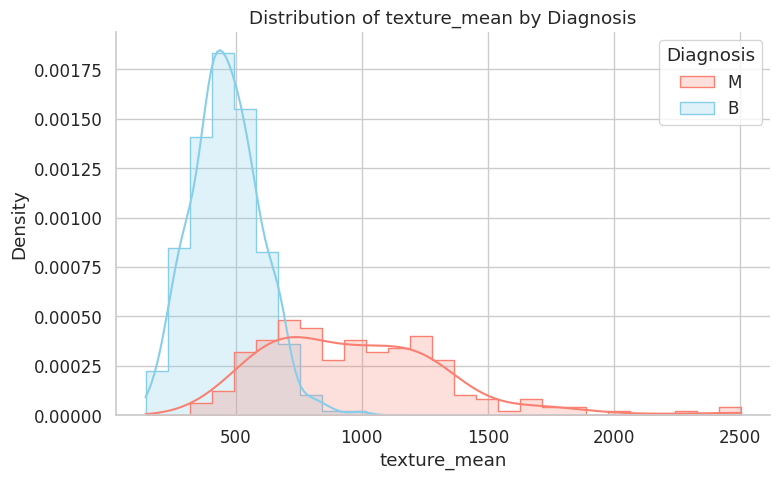

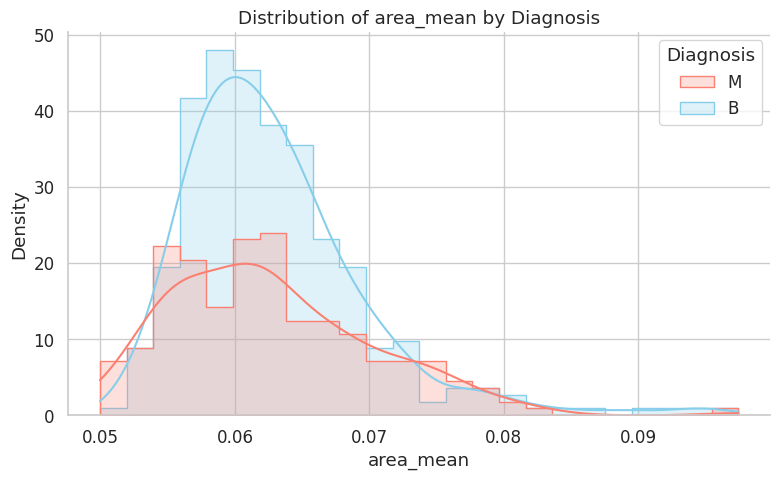

In [10]:
features = ['radius_mean','texture_mean','area_mean']

for col in features:
    # Plot density distribution grouped by diagnosis
    sns.histplot(data=df, x=col, hue='Diagnosis',
                 kde=True, element='step',
                 stat='density',
                 palette={'B': 'skyblue', 'M': 'salmon'})

    plt.title(f'Distribution of {col} by Diagnosis')
    plt.tight_layout()

    # Save plot
    saving.save_figure(f"distribution_{col}")

    plt.show()

The plots show that malignant cases generally tend to have higher values, particularly for radius_mean and area_mean, compared to benign cases.  

However, there is overlap between the two classes across all features, indicating that none of these variables alone can perfectly distinguish between benign and malignant samples.

To further explore differences across all numerical features, the variables are starndardized to remove scale differences and visualize their distributions using boxplots.

/tmp/ipykernel_10227/1498585703.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)


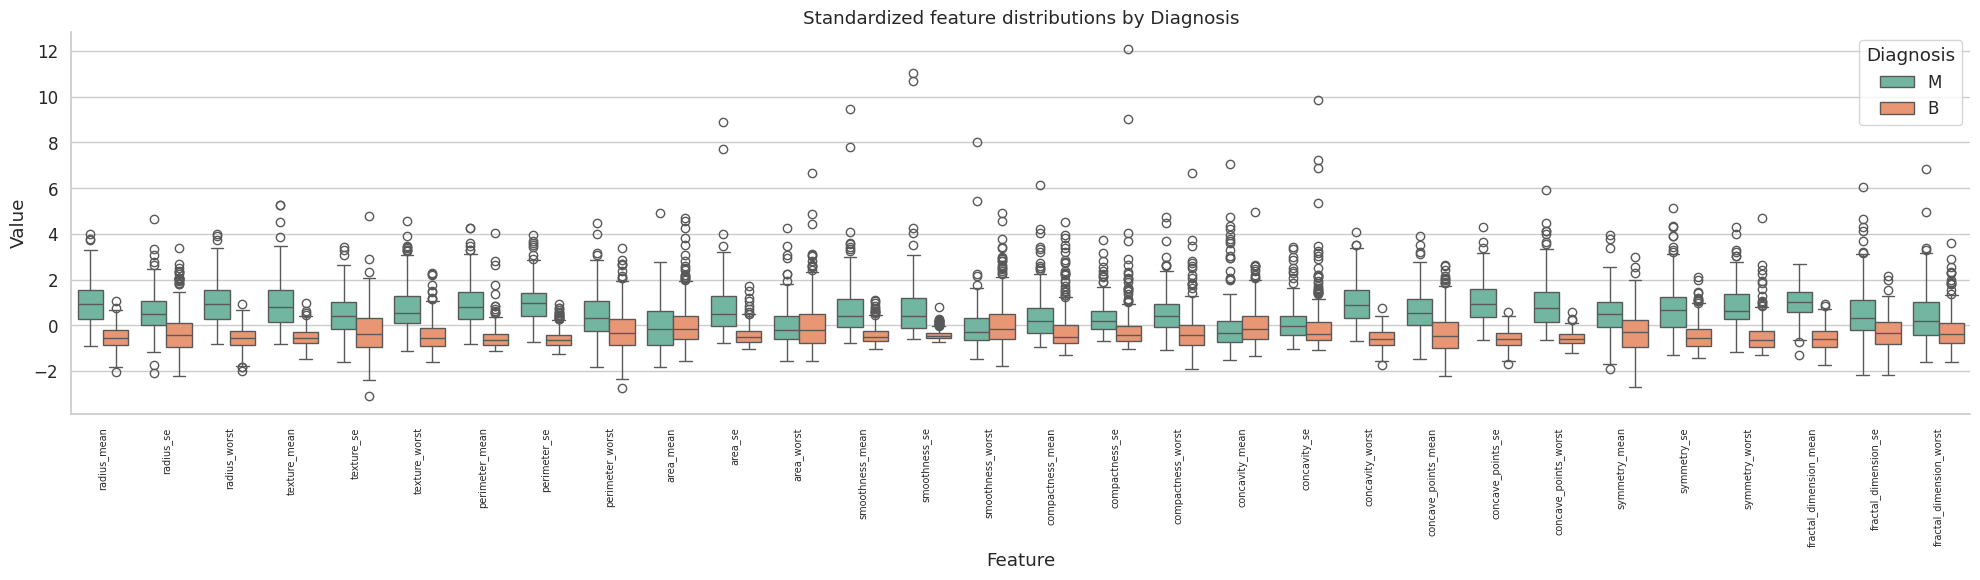

In [11]:
num_df = df.drop(columns=['Diagnosis'])
scaler = StandardScaler().fit(num_df)
df_scaled = pd.DataFrame(scaler.transform(num_df), columns=num_df.columns)
df_scaled['Diagnosis'] = df['Diagnosis'].values
df_melt = df_scaled.melt(id_vars="Diagnosis", var_name="Feature", value_name="Value")

fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(x="Feature", y="Value", hue="Diagnosis", data=df_melt, palette="Set2", ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_title('Standardized feature distributions by Diagnosis')
plt.tight_layout()
saving.save_figure("feature_boxplot")
plt.show()

The standardized boxplots confirm that several features tend to show higher values for malignant cases compared to benign ones.  

However, considerable overlap remains across most variables, reinforcing the need for a multivariate approach rather than relying on individual features.

To quantify the differences observed in the previous plots, compute the absolute mean difference between malignant and benign cases for each feature. The top 10 are then ranked them from largest to smallest.

In [12]:
# Mean per feature by diagnosis
means = df.groupby('Diagnosis').mean()

# Absolute mean difference
diff = (means.loc['M'] - means.loc['B']).abs()

diff = diff.sort_values(ascending=False)
print("Features ranked by mean difference between Malignant and Benign:")
print(diff.head(10))


Features ranked by mean difference between Malignant and Benign:
concave_points_worst   863.39
texture_mean           515.59
concave_points_se       54.36
smoothness_se           51.54
radius_worst            37.29
concavity_worst          7.76
concave_points_mean      5.80
radius_mean              5.32
radius_se                3.69
smoothness_mean          2.32
dtype: float64


Features related to area and perimeter show the largest differences between malignant and benign cases, indicating that size-related measurements may be more informative for breast cancer classification.

## **Features correlation**

The Pearson correlation matrix is computed to investigate relationship between numerical features. This helps identify highly correlated variables that may carry redundant information.

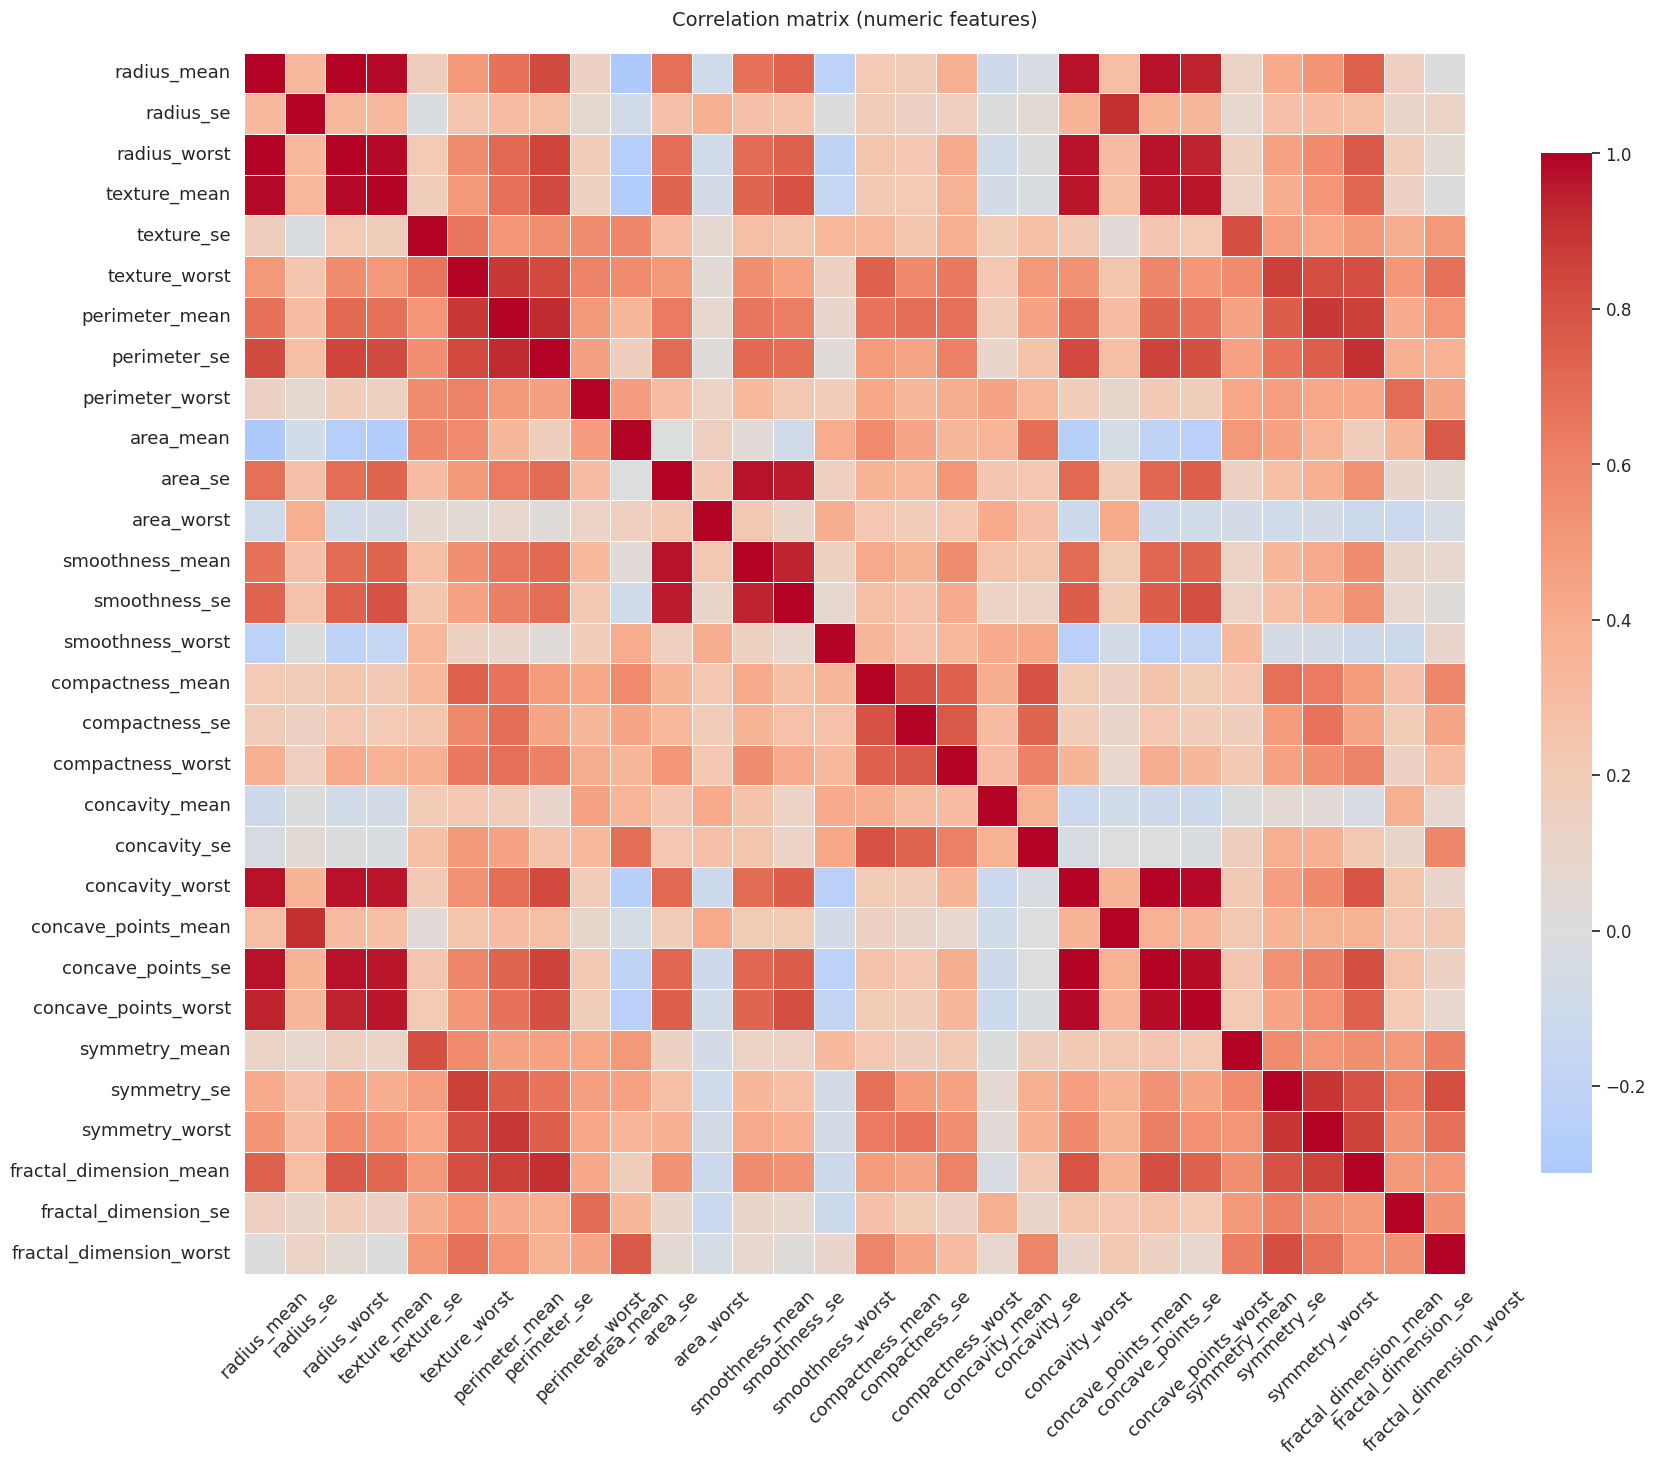

In [13]:
#Compute Pearson correlation matrix
corr = df.drop(columns=['Diagnosis']).corr(method='pearson')
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={'shrink': .8},
            ax=ax)

# Axis labels
ax.tick_params(axis='x', labelsize=13, rotation=45)
ax.tick_params(axis='y', labelsize=13, rotation=0)

# Set title and layout
ax.set_title('Correlation matrix (numeric features)', pad=20, fontsize=14)
plt.tight_layout()
saving.save_figure("correlation_matrix")
plt.show()
plt.rcParams['figure.figsize'] = (8, 5)

To further quantify the relationships observed in the heatmap, the absolute Pearson correlations are computed and ranked in descending order.

In [14]:
# Absolute Pearson correlations
num_df = df.select_dtypes(include='number')
corr_abs = num_df.corr().abs()

# Exclude self-correlations
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Print top 10 strongest correlations
sorted_corr = upper.unstack().dropna().sort_values(ascending=False)
print(sorted_corr.head(10))

radius_worst          radius_mean         1.00
concave_points_se     concavity_worst     0.99
texture_mean          radius_mean         0.99
                      radius_worst        0.99
concave_points_worst  concavity_worst     0.98
                      concave_points_se   0.98
smoothness_mean       area_se             0.97
concave_points_se     radius_worst        0.97
concavity_worst       radius_mean         0.97
                      radius_worst        0.97
dtype: float64


The strongest positive correlations are observed among geometrically related features such as radius, concavity, and concave points. These variables are all related to tumor size and shape, and therefore tend to vary together, capturing similar underlying information.

The correlation matrix confirms the presence of multicollinearity, meaning that some features are highly correlated and partially redundant. For this reason, a feature selection step is later applied in the models pipeline to reduce redundancy and improve model robustness.

##**TRAIN/TEST SPLIT**

The dataset is split into input features **X** (all numeric predictors) and target **y** (binary label: malignant=1, benign=0).  
A **stratified** train/test split is applied to preserve the original class proportions in both subsets.

In [15]:
X = df.drop(columns="Diagnosis")
y = (df["Diagnosis"] == "M").astype("int64")

# Stratified 70/30 train–test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state = 42)

# Compare class proportions in train and test sets
split_summary = (
    y_train.value_counts(normalize=True).rename("train")
    .to_frame()
    .join(y_test.value_counts(normalize=True).rename("test"))
    .rename(index={0: "benign (0)", 1: "malignant (1)"}))

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
display(split_summary)

# Saving
saving.save_dataset(pd.DataFrame(X_train), 'X_train')
saving.save_dataset(pd.DataFrame(X_test), 'X_test')
saving.save_dataset(pd.DataFrame(y_train), 'y_train')
saving.save_dataset(pd.DataFrame(y_test), 'y_test')


Train shape: (398, 30) | Test shape: (171, 30)


,train,test
Diagnosis,,
benign (0),0.63,0.63
malignant (1),0.37,0.37


Saved: data/processed/X_train.csv
Saved: data/processed/X_test.csv
Saved: data/processed/y_train.csv
Saved: data/processed/y_test.csv


## **MODEL TRAINING**

All models are trained using a consistent `Pipeline` to ensure a fair comparison.
The pipeline includes feature scaling with `StandardScaler`, feature selection with `SelectKBest(score_func=f_classif)`, and model training.
Hyperparameters are optimized using `GridSearchCV` with 5-fold cross-validation, and the same preprocessing steps are applied across all models.

### **LOGISTIC REGRESSION**

Logistic regression is a linear classification model used for binary outcomes.

The model is implemented within a pipeline composed of `StandardScaler()`, which standardizes features (mean 0, variance 1), `SelectKBest`, which selects the most relevant features, and `LogisticRegression(class_weight="balanced", max_iter=2000)`, which builds the classifier while handling class imbalance.

L1 and L2 regularization are tested, and the `liblinear` solver is used as it is suitable for small to medium-sized binary classification problems. Hyperparameters are optimized using `GridSearchCV()` with 5-fold cross-validation, tuning the number of selected features and the regularization strength (`C`).

In [16]:
# Pipeline for scaling, feature selection and logistic regression model
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("log", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))
])

# Hyperparameter grid
param_grid_log = {
    "selector__k": [10, 15, 20, 25, 30],
    "log__C": [0.01, 0.1, 1, 10],
    "log__penalty": ["l1", "l2"],
    "log__solver": ["liblinear"]
}

# GridSearch with 5-fold cross-validation optimizing F1 score
grid_log = GridSearchCV(
    pipe_log,
    param_grid_log,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train model
grid_log.fit(X_train, y_train)

# Best model after tuning
best_log = grid_log.best_estimator_
saving.save_model(best_log, "logistic_regression")

In [17]:
print("Best LOG parameters:", grid_log.best_params_)
print("Best CV F1 score:", grid_log.best_score_)

Best LOG parameters: {'log__C': 1, 'log__penalty': 'l2', 'log__solver': 'liblinear', 'selector__k': 30}
Best CV F1 score: 0.9621647788166265


In [18]:
# Predict class labels and probabilities
y_pred_log = best_log.predict(X_test)
y_proba_log = best_log.predict_proba(X_test)[:, 1]

#### **Model evaluation**

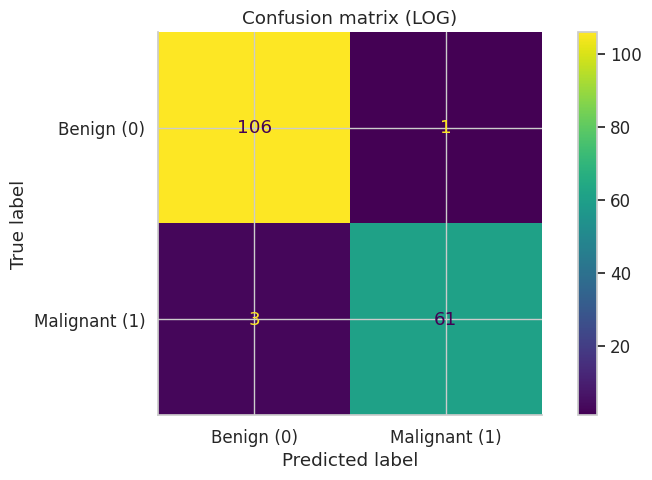

In [19]:
# Compute and plot confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    cm_log,
    display_labels=["Benign (0)", "Malignant (1)"]
).plot(values_format="d")

plt.title("Confusion matrix (LOG)")
plt.tight_layout()
saving.save_figure("confusion_matrix_log")
plt.show()

In [20]:
# Classification report and evaluation metrics
print(classification_report(y_test, y_pred_log, target_names=["Benign", "Malignant"]))

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98       107
   Malignant       0.98      0.95      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

Accuracy: 0.9766081871345029
Precision: 0.9838709677419355
Recall: 0.953125
F1 score: 0.9682539682539683
ROC-AUC: 0.9969334112149533


### **SUPPORT VECTOR MACHINE (SVM)**


A Support Vector Machine (SVM) with RBF kernel is used to capture non-linear patterns in the data.

The model is implemented within a pipeline composed of `StandardScaler()`, which standardizes features, `SelectKBest`, which selects the most relevant features based on statistical tests, and `SVC(class_weight="balanced", probability=True)`, which builds the classifier while handling class imbalance and enabling probability estimation.

Hyperparameters are optimized using `GridSearchCV()`, which performs cross-validated search over different parameter combinations (e.g. `C`, `gamma`, and number of selected features).

In [21]:
# Pipeline for scaling, feature selection and SVM model
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("svm", SVC(class_weight="balanced", probability=True, random_state=42))
])

# Hyperparameter grid
param_grid = {
    "selector__k": [10, 15, 20, 25, 30],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": ["scale", 0.1, 0.01],
    "svm__kernel": ["rbf"]
}

# GridSearch with 5-fold cross-validation optimizing F1 score
grid_svm = GridSearchCV(pipe_svm, param_grid, cv=5, scoring="f1")

# Train model
grid_svm.fit(X_train, y_train)

# Best model after tuning
best_svm = grid_svm.best_estimator_
saving.save_model(best_svm, "svm")

In [22]:
print("Best SVM parameters:", grid_svm.best_params_)
print("Best CV F1 score:", grid_svm.best_score_)

Best SVM parameters: {'selector__k': 20, 'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV F1 score: 0.9682302839195079


In [23]:
# Predict labels and probabilities
y_pred_svm = best_svm.predict(X_test)
y_prob_svm = best_svm.predict_proba(X_test)[:, 1]

#### **Model Evaluation**

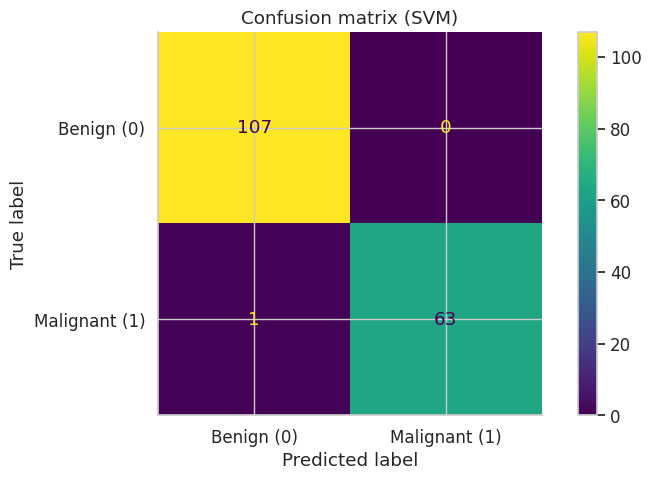

In [24]:
# Compute and plot confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

ConfusionMatrixDisplay(
    cm_svm,
    display_labels=["Benign (0)", "Malignant (1)"]
).plot(values_format="d")

plt.title("Confusion matrix (SVM)")
plt.tight_layout()
saving.save_figure("confusion_matrix_svm")
plt.show()

In [25]:
# Classification report and evaluation metrics
print(classification_report(y_test, y_pred_svm, target_names=["Benign", "Malignant"]))

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

              precision    recall  f1-score   support

      Benign       0.99      1.00      1.00       107
   Malignant       1.00      0.98      0.99        64

    accuracy                           0.99       171
   macro avg       1.00      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171

Accuracy: 0.9941520467836257
Precision: 1.0
Recall: 0.984375
F1 score: 0.9921259842519685
ROC-AUC: 0.9976635514018691


###**LINEAR DISCRIMINANT ANALYSIS (LDA)**

Linear Discriminant Analysis (LDA) is used as a linear classifier that models class separation based on feature distributions.

The model is implemented within a pipeline composed of `StandardScaler()`, which standardizes features, `SelectKBest`, which selects the most relevant features, and `LinearDiscriminantAnalysis()`, which performs classification by maximizing class separability.

Hyperparameters are optimized using `GridSearchCV()` with 5-fold cross-validation, tuning the number of selected features (`selector__k`), the solver (`svd`, `lsqr`), and the shrinkage parameter to improve model stability.

In [26]:
# Pipeline for scaling, feature selection and LDA model
pipe_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("lda", LinearDiscriminantAnalysis())
])

# Hyperparameter grid
param_grid_lda = [
    {
        "selector__k": [20, 25, 30],
        "lda__solver": ["svd"],
        "lda__shrinkage": [None]
    },
    {
        "selector__k": [20, 25, 30],
        "lda__solver": ["lsqr"],
        "lda__shrinkage": [None, "auto"]
    }
]

# GridSearch with 5-fold cross-validation optimizing F1 score
grid_lda = GridSearchCV(
    pipe_lda,
    param_grid_lda,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train model
grid_lda.fit(X_train, y_train)

# Best model after tuning
best_lda = grid_lda.best_estimator_
saving.save_model(best_lda, "lda")

In [27]:
# Predict labels and probabilities
y_pred_lda = best_lda.predict(X_test)
y_proba_lda = best_lda.predict_proba(X_test)[:, 1]

In [28]:
print("Best LDA parameters:", grid_lda.best_params_)
print("Best CV F1 score:", grid_lda.best_score_)

Best LDA parameters: {'lda__shrinkage': 'auto', 'lda__solver': 'lsqr', 'selector__k': 25}
Best CV F1 score: 0.9418310364771344


####**Model Evaluation**

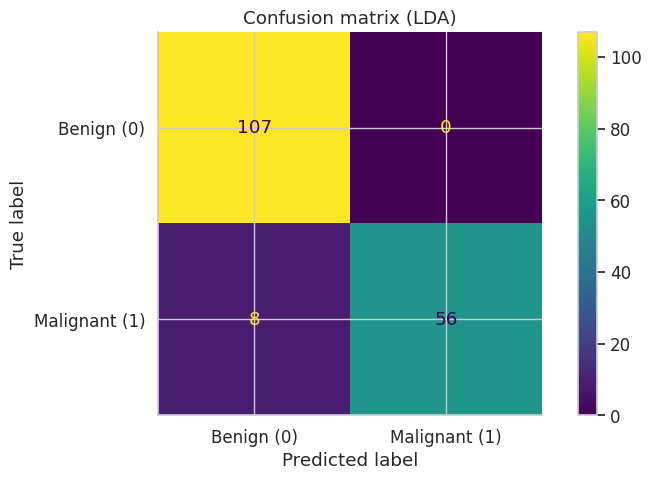

In [29]:
# Compute and plot confusion matrix
cm_lda = confusion_matrix(y_test, y_pred_lda)

ConfusionMatrixDisplay(
    cm_lda,
    display_labels=["Benign (0)", "Malignant (1)"]
).plot(values_format="d")

plt.title("Confusion matrix (LDA)")
plt.tight_layout()
saving.save_figure("confusion_matrix_lda")
plt.show()

In [30]:
# Classification report and evaluation metrix
print(classification_report(y_test, y_pred_lda, target_names=["Benign", "Malignant"]))

print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print("Precision:", precision_score(y_test, y_pred_lda, pos_label=1))
print("Recall:", recall_score(y_test, y_pred_lda, pos_label=1))
print("F1 score:", f1_score(y_test, y_pred_lda, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lda))

              precision    recall  f1-score   support

      Benign       0.93      1.00      0.96       107
   Malignant       1.00      0.88      0.93        64

    accuracy                           0.95       171
   macro avg       0.97      0.94      0.95       171
weighted avg       0.96      0.95      0.95       171

Accuracy: 0.9532163742690059
Precision: 1.0
Recall: 0.875
F1 score: 0.9333333333333333
ROC-AUC: 0.9988317757009346


###**K-NEAREST NEIGHBORS (KNN)**

K-Nearest Neighbors (KNN) is used as a distance-based classifier that assigns labels based on the nearest training examples.

The model is implemented within a pipeline composed of `StandardScaler()`, which standardizes features, `SelectKBest`, which selects the most relevant features, and `KNeighborsClassifier()`, which performs classification based on feature similarity.

Hyperparameters are optimized using `GridSearchCV()` with 5-fold cross-validation, tuning the number of selected features (`selector__k`), the number of neighbors (`n_neighbors`), the weighting scheme (`uniform`, `distance`), and the distance metric (`euclidean`, `manhattan`).

In [31]:
# Pipeline for scaling, feature selection and KNN model
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier())
])

# Hyperparameter grid
param_grid_knn = {
    "selector__k": [10, 15, 20, 25, 30],
    "knn__n_neighbors": [3, 5, 7, 9, 11, 15],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

# GridSearch with 5-fold cross-validation optimizing F1 score
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid_knn,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train model
grid_knn.fit(X_train, y_train)

# Best model after tuning
best_knn = grid_knn.best_estimator_
saving.save_model(best_knn, "knn")

In [32]:
# Predict labels and probabilities
y_pred_knn = best_knn.predict(X_test)
y_proba_knn = best_knn.predict_proba(X_test)[:, 1]

In [33]:
print("Best k-NN parameters:", grid_knn.best_params_)
print("Best CV F1 score:", grid_knn.best_score_)

Best k-NN parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform', 'selector__k': 25}
Best CV F1 score: 0.9640995143225295


#### **Model Evaluation**

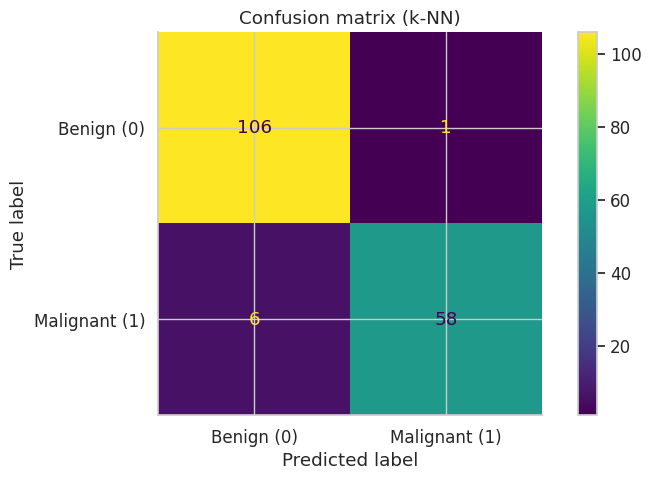

In [34]:
# Compute and pot confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

ConfusionMatrixDisplay(
    cm_knn,
    display_labels=["Benign (0)", "Malignant (1)"]
).plot(values_format="d")

plt.title("Confusion matrix (k-NN)")
plt.tight_layout()
saving.save_figure("confusion_matrix_knn")
plt.show()

In [35]:
# Classification report and evaluation metrics
print(classification_report(y_test, y_pred_knn, target_names=["Benign", "Malignant"]))

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, pos_label=1))
print("Recall:", recall_score(y_test, y_pred_knn, pos_label=1))
print("F1 score:", f1_score(y_test, y_pred_knn, pos_label=1))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_knn))

              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97       107
   Malignant       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

Accuracy: 0.9590643274853801
Precision: 0.9830508474576272
Recall: 0.90625
F1 score: 0.943089430894309
ROC-AUC: 0.9798481308411214


##**MODEL COMPARISON**

Model performance is compared using **ROC** and **Precision–Recall** curves, which help visualize how well each model separates the classes across different thresholds.

More evaluation metrics (**Accuracy**, **Precision**, **Recall**, **F1 score**, **ROC-AUC**, and **Average Precision**) are also computed to provide a clear and quantitative comparison.

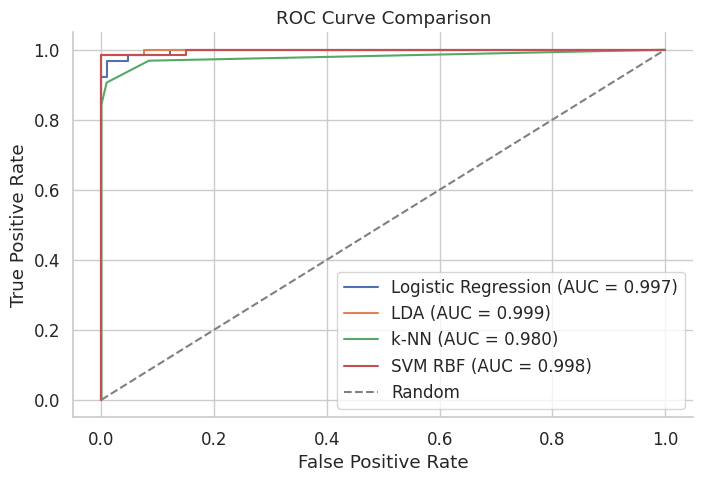

In [36]:
# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
auc_log = auc(fpr_log,tpr_log)

# LDA
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_proba_lda)
auc_lda = auc(fpr_lda, tpr_lda)

# KNN
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
auc_knn = auc(fpr_knn, tpr_knn)

# SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)


plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot(fpr_lda, tpr_lda, label=f"LDA (AUC = {auc_lda:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"k-NN (AUC = {auc_knn:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM RBF (AUC = {auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)

saving.save_figure("roc_curve_comparison")

plt.show()

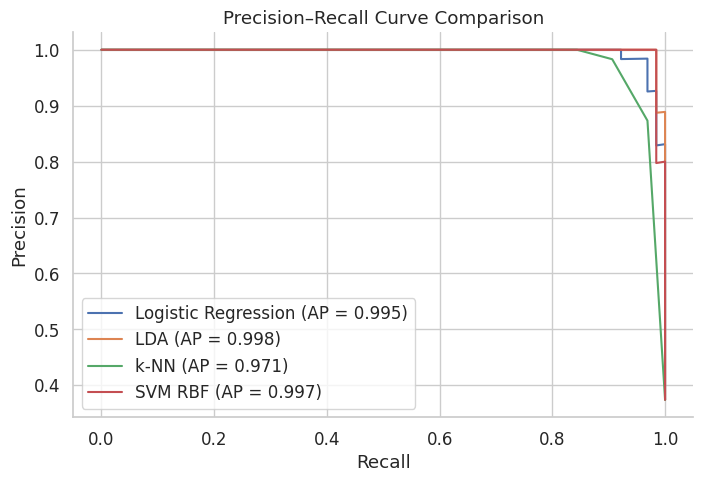

In [37]:
# Precision–Recall curve and Average Precision for Logistic Regression
prec_log, rec_log, _ = precision_recall_curve(y_test, y_proba_log)
ap_log = average_precision_score(y_test, y_proba_log)

# Precision–Recall curve and Average Precision for SVM
prec_svm, rec_svm, _ = precision_recall_curve(y_test, y_prob_svm)
ap_svm = average_precision_score(y_test, y_prob_svm)

# Precision-Recall curve and Average Precision for LDA
prec_lda, rec_lda, _ = precision_recall_curve(y_test, y_proba_lda)
ap_lda = average_precision_score(y_test, y_proba_lda)

# Precision-Recall curve and Average Precision for k-NN
prec_knn, rec_knn, _ = precision_recall_curve(y_test, y_proba_knn)
ap_knn = average_precision_score(y_test, y_proba_knn)

# PR curves
plt.plot(rec_log, prec_log, label=f"Logistic Regression (AP = {ap_log:.3f})")
plt.plot(rec_lda, prec_lda, label=f"LDA (AP = {ap_lda:.3f})")
plt.plot(rec_knn, prec_knn, label=f"k-NN (AP = {ap_knn:.3f})")
plt.plot(rec_svm, prec_svm, label=f"SVM RBF (AP = {ap_svm:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.grid(True)

saving.save_figure("pr_curve_comparison")

plt.show()

In [38]:
# Logistic
metrics_log = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_proba_log),
    "PR-AUC (AP)": average_precision_score(y_test, y_proba_log)
}

# SVM
metrics_svm = {
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1": f1_score(y_test, y_pred_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm),
    "PR-AUC (AP)": average_precision_score(y_test, y_prob_svm)
}

# LDA
metrics_lda = {
    "Model": "LDA",
    "Accuracy": accuracy_score(y_test, y_pred_lda),
    "Precision": precision_score(y_test, y_pred_lda),
    "Recall": recall_score(y_test, y_pred_lda),
    "F1": f1_score(y_test, y_pred_lda),
    "ROC-AUC": roc_auc_score(y_test, y_proba_lda),
    "PR-AUC (AP)": average_precision_score(y_test, y_proba_lda)
}

# KNN
metrics_knn = {
    "Model": "k-NN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1": f1_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_proba_knn),
    "PR-AUC (AP)": average_precision_score(y_test, y_proba_knn)
}

results = pd.DataFrame([
    metrics_log,
    metrics_svm,
    metrics_lda,
    metrics_knn
])

# Saving
saving.save_results(results, "model_comparison_metrics", folder="results")

results

Saved: results/model_comparison_metrics.csv


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC (AP)
0,Logistic Regression,0.98,0.98,0.95,0.97,1.00,1.00
1,SVM (RBF),0.99,1.00,0.98,0.99,1.00,1.00
2,LDA,0.95,1.00,0.88,0.93,1.00,1.00
3,k-NN,0.96,0.98,0.91,0.94,0.98,0.97
